Directory 'output' already exists.
Directory 'plots' already exists.


<Figure size 640x480 with 0 Axes>

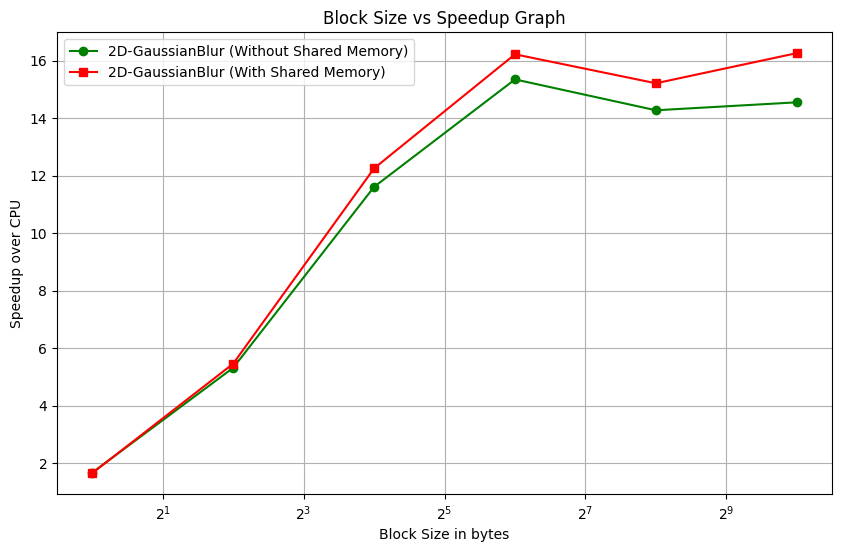

In [8]:
# HPC Labwork 5 : Gaussian Blur Convolution
# by Lucien Elyas Bedrane - 2640012

#!pip install numba

import numba
import matplotlib.pyplot as plt
import numpy as np
import time
import math
import statistics as stats
import os
import cv2

from numba import cuda

#We create the 7x7 gaussian kernel using the mathematical formula
def get_gaussian_kernel(size=7, sigma=1.0):
    kernel = np.zeros((size, size))
    center = size // 2
    for y in range(size):
        for x in range(size):
            dx = x - center
            dy = y - center
            kernel[y, x] = (1.0 / (2.0 * math.pi * sigma**2)) * math.exp(-(dx**2 + dy**2) / (2.0 * sigma**2))
    return kernel / np.sum(kernel)

#We define the CPU version of gaussian blur
#We compile the CPU implementation with Numba JIT (nopython mode)
#to eliminate pure Python loop overhead (which exceeds 30 minutes on 8K images).
#This provides a fair, pure C-speed sequential baseline with identical nested-loop logic.
@numba.jit(nopython=True)
def gaussian_blur_CPU(src, kernel):
    height, width, channels = src.shape
    dst = np.zeros_like(src)
    r = 3  # Radius for 7x7 kernel

    # We loop over image pixels excluding borders
    for y in range(r, height - r):
        for x in range(r, width - r):
            for c in range(channels):
                val = 0.0
                for ky in range(-r, r + 1):
                    for kx in range(-r, r + 1):
                        val += src[y + ky, x + kx, c] * kernel[ky + r, kx + r]
                dst[y, x, c] = val
    return dst

#We define here the 2D GPU version of gaussian blur without shared memory
@cuda.jit
def gaussian_blur_GPU_2D(src, dst, kernel):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

    height, width, channels = src.shape
    r = 3

    if r <= tidy < height - r and r <= tidx < width - r:
        for c in range(channels):
            val = 0.0
            for ky in range(-r, r + 1):
                for kx in range(-r, r + 1):
                    val += src[tidy + ky, tidx + kx, c] * kernel[ky + r, kx + r]
            dst[tidy, tidx, c] = val

#We define the 2D GPU version of gaussian blur with shared memory
@cuda.jit
def gaussian_blur_GPU_2D_shared(src, dst, kernel):
    s_kernel = cuda.shared.array(shape=(7, 7), dtype=numba.float32)

    tx = cuda.threadIdx.x
    ty = cuda.threadIdx.y

    if ty < 7 and tx < 7:
        s_kernel[ty, tx] = kernel[ty, tx]

    cuda.syncthreads()  #We use this as cuda.synchronize() doesn't work

    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

    height, width, channels = src.shape
    r = 3

    if r <= tidy < height - r and r <= tidx < width - r:
        for c in range(channels):
            val = 0.0
            for ky in range(-r, r + 1):
                for kx in range(-r, r + 1):
                    val += src[tidy + ky, tidx + kx, c] * s_kernel[ky + r, kx + r]
            dst[tidy, tidx, c] = val

#We create folders the different outputs that we will generate
for directory_name in ["output", "plots"] :
    try:
        os.mkdir(directory_name)
        print(f"Directory '{directory_name}' created successfully.")
    except FileExistsError:
        print(f"Directory '{directory_name}' already exists.")
    except PermissionError:
        print(f"Permission denied: Unable to create '{directory_name}'.")
    except Exception as e:
        print(f"An error occurred: {e}")

#We load here the source image
img = plt.imread('src/lake.png')
if img.shape[2] == 4:
    img = img[:, :, :3]

#We generate the gaussian kernel matrix
gaussian_kernel = get_gaussian_kernel(7, 1.0)

#We initialize the blockSize and gridSize that will be used to test the 2D GPU versions of gaussian blur
blockSize2D = [(2**x, 2**x) for x in range(6)]
gridSize2D = [(int(np.ceil(img.shape[1] / x[0])), int(np.ceil(img.shape[0] / x[1]))) for x in blockSize2D]

#We copy here into the GPU memory the source image and gaussian kernel
devSrc2D = cuda.to_device(img)
devKernel = cuda.to_device(gaussian_kernel)
devDst2D = cuda.device_array(img.shape, np.float32)

time_records_2D = []

#In this loop, we try the GPU version of gaussian_blur_GPU_2D with different size of blocks and grids
for i in range(len(blockSize2D)):
    cuda.synchronize()
    start_time = time.time()
    gaussian_blur_GPU_2D[gridSize2D[i], blockSize2D[i]](devSrc2D, devDst2D, devKernel)
    hostDst2D = devDst2D.copy_to_host()
    cuda.synchronize()
    end_time = time.time()

    time_records_2D.append(end_time - start_time)

    plt.imsave("output/gpu_2D_output_" + str(i) + ".png", hostDst2D)

time_records_2D_shared = []

#In this loop, we try the GPU version of gaussian_blur_GPU_2D_shared with different size of blocks and grids
for i in range(len(blockSize2D)):
    cuda.synchronize()
    start_time = time.time()
    gaussian_blur_GPU_2D_shared[gridSize2D[i], blockSize2D[i]](devSrc2D, devDst2D, devKernel)
    hostDst2D = devDst2D.copy_to_host()
    cuda.synchronize()
    end_time = time.time()

    time_records_2D_shared.append(end_time - start_time)

    plt.imsave("output/gpu_2D_shared_output_" + str(i) + ".png", hostDst2D)

#We use the CPU version of gaussian blur
start_time_cpu = time.time()
cpu_image = gaussian_blur_CPU(img, gaussian_kernel)
end_time_cpu = time.time()
time_cpu = end_time_cpu - start_time_cpu
plt.imsave("output/cpu_output.png", cpu_image)

#We compute the speedup for each version compared to the CPU version
speedup_2D = [time_cpu / t for t in time_records_2D]
speedup_2D_shared = [time_cpu / t for t in time_records_2D_shared]

#We plot and save the graph of Block Size vs Speedup
plt.clf()
plt.figure(figsize=(10, 6))
plt.xscale('log', base=2)
plt.plot([x[0]**2 for x in blockSize2D], speedup_2D, linestyle="-", color="green", marker="o", label="2D-GaussianBlur (Without Shared Memory)")
plt.plot([x[0]**2 for x in blockSize2D], speedup_2D_shared, linestyle="-", color="red", marker="s", label="2D-GaussianBlur (With Shared Memory)")
plt.legend()
plt.title("Block Size vs Speedup Graph")
plt.xlabel("Block Size in bytes")
plt.ylabel("Speedup over CPU")
plt.grid(True)
plt.savefig("plots/BlockSize_vs_Speedup_Graph.png")